# Инструменты для анализа и предобработки данных

Цель данной лабораторной работы - вспомнить инструментарий pandas, SQL и matplotlib для проведения анализа и предобработки данных.

С точки зрения машинного обучения в данной работе будет рассмотрен алгоритм kNN, алгоритм кластеризации kMeans, а также некоторые методы снижения размерности.

Датасет, с которым вам предстоит работать, содержит информацию о покупателях в одном из магазинов. Данные разделены на несколько файлов.
<br><br>
**people**

`id`: уникальный идентификатор клиента

`year_birth`: год рождения клиента

`education`: уровень образования клиента

`marital_status`: семейное положение клиента

`income`: годовой доход семьи клиента

`kidhome`: количество детей в доме клиента

`teenhome`: количество подростков в доме клиента

`dt_customer`: дата регистрации клиента в компании

`recency`: количество дней с момента последней покупки клиента

`complain`: 1, если клиент жаловался в последние 2 года, 0 в противном случае
<br><br>
**products**

`id`: уникальный идентификатор клиента

`mntwines`: сумма, потраченная на вино за последние 2 года

`mntfruits`: сумма, потраченная на фрукты за последние 2 года

`mntmeatproducts`: сумма, потраченная на мясные продукты за последние 2 года

`mntfishproducts`: сумма, потраченная на рыбу за последние 2 года

`mntsweetproducts`: сумма, потраченная на сладости за последние 2 года

`mntgoldprods`: сумма, потраченная на золото за последние 2 года
<br><br>
**purchases**

`id`: уникальный идентификатор клиента

`numwebpurchases`: количество покупок через веб-сайт компании

`numcatalogpurchases`: количество покупок с использованием каталога

`numstorepurchases`: количество покупок непосредственно в магазинах

`numwebvisitsmonth`: количество посещений веб-сайта компании в последний месяц

`numdealspurchases`: количество покупок скидочных товаров

In [51]:
!pip3 install gdown

In [53]:
!gdown 1LUjAJR6hNs5IAnQscisvM2hUemvYRLWy
!unzip customers.zip

Downloading...
From: https://drive.google.com/uc?id=1LUjAJR6hNs5IAnQscisvM2hUemvYRLWy
To: /Users/vikafg/Documents/GitHub/ml-labs/customers.zip
100%|███████████████████████████████████████| 66.6k/66.6k [00:00<00:00, 483kB/s]
Archive:  customers.zip
replace products.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

OSError: [Errno 5] Input/output error

## pandas, sql

Прочитайте данные. Сколько строк и столбцов содержат таблицы? Есть ли в данных пропуски?

In [54]:
# PUT YOUR CODE HERE
import pandas as pd

people_df = pd.read_csv('data_lab2/people.csv', delimiter=';')
products_df = pd.read_csv('data_lab2/products.csv', delimiter='\t')
purchases_df = pd.read_csv('data_lab2/purchases.csv')

dfs = [people_df, products_df, purchases_df]

for df in dfs:
    # размер
    rows, cols = df.shape
    print(f'Строк: {rows}, колонок: {cols}')

    # пропуски
    missing_total = df.isnull().sum().sum()
    print(f'Всего пропусков: {missing_total}')

    if missing_total > 0:
        print('Пропуски по стобцам:')
        print(df.isnull().sum())

    print()


Строк: 2240, колонок: 10
Всего пропусков: 24
Пропуски по стобцам:
id                 0
year_birth         0
education          0
marital_status     0
income            24
kidhome            0
teenhome           0
dt_customer        0
recency            0
complain           0
dtype: int64

Строк: 2240, колонок: 7
Всего пропусков: 0

Строк: 2240, колонок: 6
Всего пропусков: 0



Каждое из следующих заданий необходимо выполнить двумя способами - с помощью pandas и с помощью SQL. Не используйте объединение таблиц через join/merge/concat.

In [55]:
import sqlite3

conn = sqlite3.connect(':memory:')  # создание временной базы данных

people_df.to_sql('people', conn, index=False)
products_df.to_sql('products', conn, index=False)
purchases_df.to_sql('purchases', conn, index=False)

query = "SELECT * FROM people LIMIT 5;"
result = pd.read_sql_query(query, conn)
result

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,complain
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,0
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,0


### 1

Найдите абсолютную разницу между минимальным доходом клиентов с детьми и максимальным доходом клиентов без детей. Учитывайте только столбец `kidhome`.

In [56]:
# PUT YOUR PANDAS CODE HERE
# уберём пропуски в income
people = people_df.dropna(subset=['income'])

with_kids = people[people['kidhome'] > 0]
without_kids = people[people['kidhome'] == 0]

min_income_with_kids = with_kids['income'].min()
max_income_without_kids = without_kids['income'].max()

print(f'Разница: {min_income_with_kids - max_income_without_kids}')


Разница: -158356.0


In [57]:
# PUT YOUR SQL CODE HERE
query = '''
SELECT (SELECT MIN(income) FROM people WHERE kidhome > 0)
       -
       (SELECT MAX(income) FROM people WHERE kidhome = 0)
AS income_diff;
'''

result = pd.read_sql_query(query, conn)
result

,income_diff
0,-158356.0


### 2
Посчитайте процентное соотношение клиентов, имеющих PhD или другой уровень образования, среди клиентов, покупающих и не покупающих сладкое. Ответ представьте в виде:

<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <style>
        th, td {
            text-align: center;
            padding: 10px;
        }
        th {
            font-weight: bold;
        }
    </style>
</head>
<body>

<table border="1">
  <tr>
    <th></th>
    <th>PhD</th>
    <th>Other</th>
  </tr>
  <tr>
    <th>Sweets</th>
    <td>percentage</td>
    <td>percentage</td>
  </tr>
  <tr>
    <th>No Sweets</th>
    <td>percentage</td>
    <td>percentage</td>
  </tr>
</table>

</body>
</html>

Сумма по строке должна давать единицу.

In [58]:
# PUT YOUR PANDAS CODE HERE
unique_education = people_df['education'].unique()
print(f'Уникальные значения образования: {unique_education}')

# mntsweetproducts

# сопоставление education через map (без merge/join)
id_to_education = people_df.set_index('id')['education']

products_with_edu = products_df.copy()
products_with_edu['education'] = products_with_edu['id'].map(id_to_education)

# покупают сладкое или нет
products_with_edu['buys_sweets'] = products_with_edu['mntsweetproducts'] > 0

# имеют PhD или нет
products_with_edu['is_phd'] = products_with_edu['education'] == 'PhD'

# процентное соотношение
result = (
    products_with_edu.groupby('buys_sweets')['is_phd']
    .value_counts(normalize=True)  # доли
    .mul(100)  # в проценты
    .rename('percent')
    .reset_index()
)

print(result)

# сумма по строкам должна давать 100
result.groupby('buys_sweets')['percent'].sum()

Уникальные значения образования: ['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']
   buys_sweets  is_phd    percent
0        False   False  63.484487
1        False    True  36.515513
2         True   False  81.713344
3         True    True  18.286656


buys_sweets
False    100.0
True     100.0
Name: percent, dtype: float64

In [60]:
# PUT YOUR SQL CODE HERE
# Используем IN/NOT IN с подзапросами — без явного JOIN
query = '''
SELECT
    CASE WHEN mntsweetproducts > 0 THEN 1 ELSE 0 END AS buys_sweets,
    COUNT(CASE WHEN id IN (SELECT id FROM people WHERE education = 'PhD') THEN 1 END) * 100.0 / COUNT(*) AS phd_percent,
    COUNT(CASE WHEN id NOT IN (SELECT id FROM people WHERE education = 'PhD') THEN 1 END) * 100.0 / COUNT(*) AS other_percent
FROM products
GROUP BY buys_sweets;
'''

result = pd.read_sql_query(query, conn)
result

## EDA

Изучите графики, которые предлагает построить Google Colab. Какие из них несут смысл, а какие выглядят бесполезными? На основании изученных графиков сформулируйте любую гипотезу по данным и постройте график, который поможет подтвердить или опровергнуть вашу гипотезу. Ваш график должен отличаться от уже представленных!

**people**

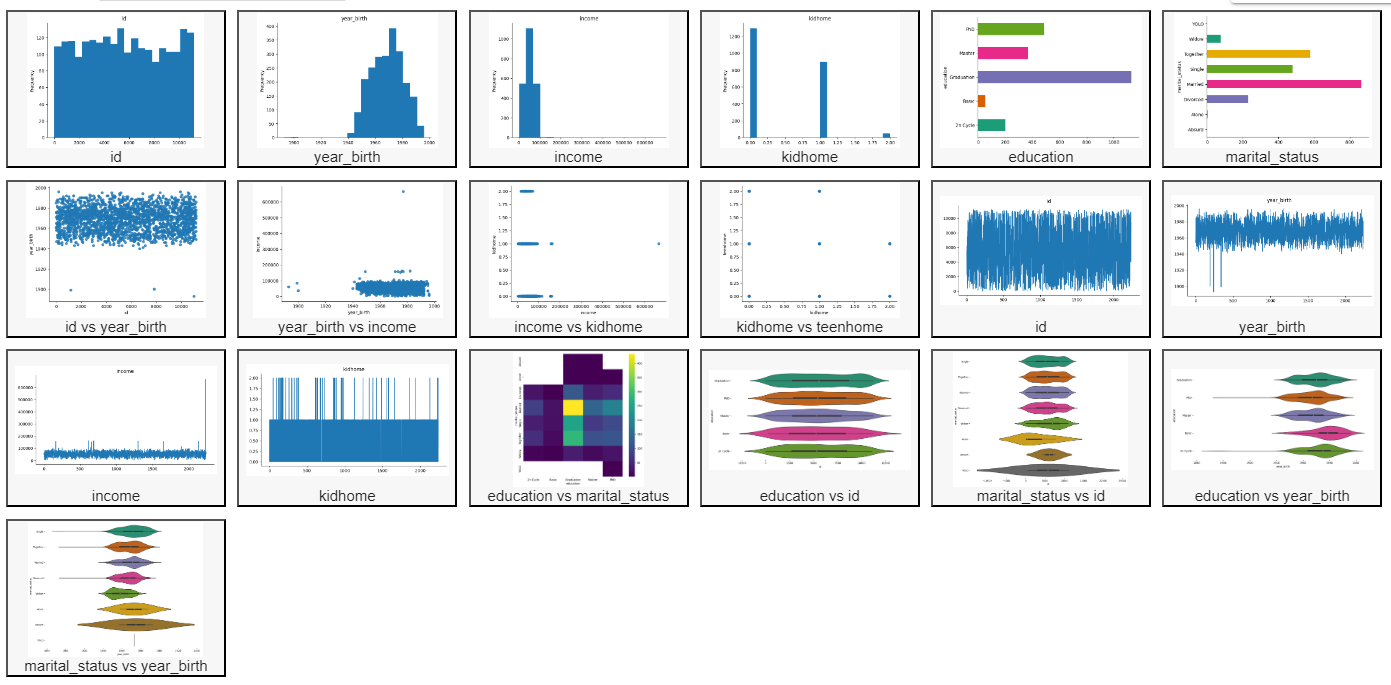

**products**

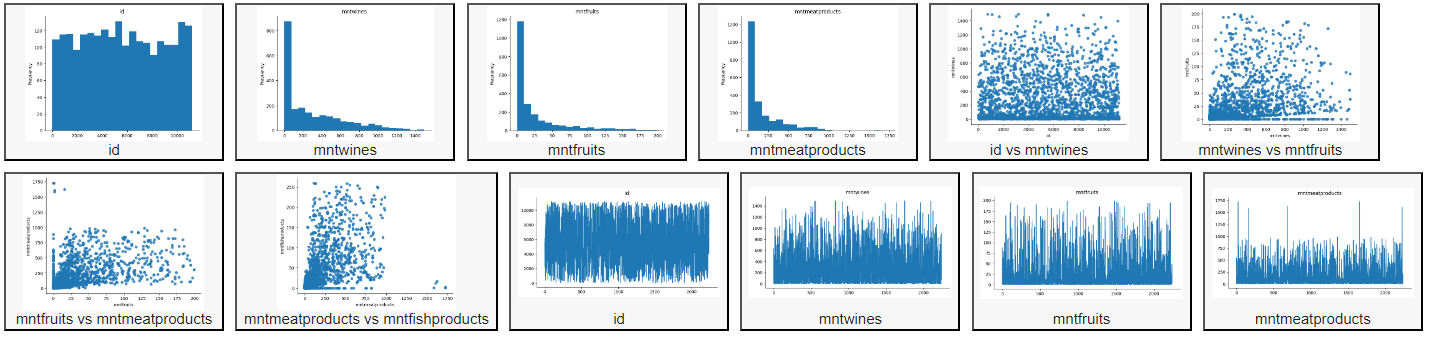

**purchases**

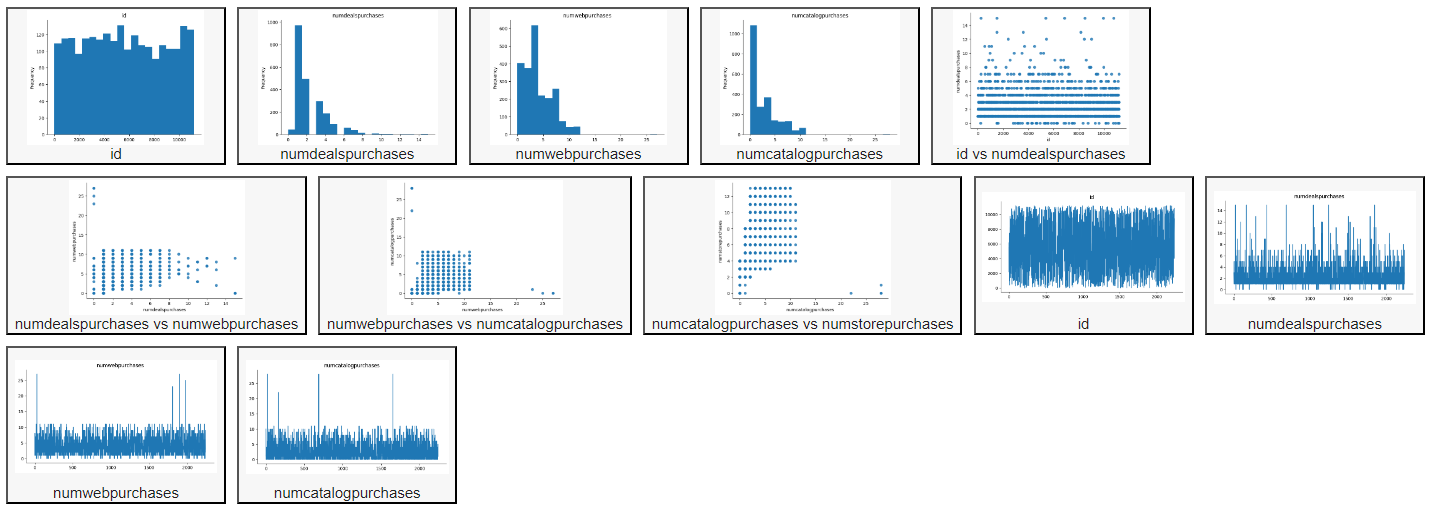

Место для вашей гипотезы.

### Бесполезные графики

1. Все графики, где в названии есть id, не несут никакой смысловой нагрузки.
2. Scatter с дискретными переменными (kidhome vs teenhome, income vs kidhome) из-за того, что значения маленькие и точки накладываются друг на друга

### Гипотеза

Клиенты без детей тратят на вино в среднем **более чем в два раза больше**, чем клиенты с детьми (kidhome > 0). Разница является статистически значимой (критерий Манна–Уитни, p < 0.05).

In [67]:
# PUT YOUR CODE HERE
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

df_hyp = people_df.copy()
df_hyp['mntwines'] = products_df.set_index('id')['mntwines'].reindex(df_hyp['id']).values
df_hyp['has_kids'] = df_hyp['kidhome'] > 0
df_hyp['group'] = df_hyp['has_kids'].map({False: 'Без детей', True: 'С детьми'})

no_kids   = df_hyp[df_hyp['has_kids'] == False]['mntwines']
with_kids = df_hyp[df_hyp['has_kids'] == True]['mntwines']

stat, p_value = stats.mannwhitneyu(no_kids, with_kids, alternative='greater')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Violin + strip plot — показывает форму распределения
sns.violinplot(data=df_hyp, x='group', y='mntwines', palette='Set2',
               inner=None, ax=axes[0])
sns.stripplot(data=df_hyp, x='group', y='mntwines', color='black',
              alpha=0.2, size=2, jitter=True, ax=axes[0])
axes[0].set_title('Распределение трат на вино')
axes[0].set_xlabel('')
axes[0].set_ylabel('Траты на вино за 2 года ($)')

# Среднее со стандартной ошибкой
means = df_hyp.groupby('group')['mntwines'].agg(['mean', 'sem'])
axes[1].bar(means.index, means['mean'], yerr=means['sem'],
            capsize=5, color=['#66c2a5', '#fc8d62'])
axes[1].set_title('Среднее ± SE трат на вино')
axes[1].set_xlabel('')
axes[1].set_ylabel('Среднее трат на вино ($)')

plt.suptitle(f'Траты на вино: дети vs. без детей  (p = {p_value:.4f})', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Медиана (без детей):   {no_kids.median():.1f}$')
print(f'Медиана (с детьми):    {with_kids.median():.1f}$')
print(f'Среднее (без детей):   {no_kids.mean():.1f}$')
print(f'Среднее (с детьми):    {with_kids.mean():.1f}$')
print(f'Mann-Whitney U: stat={stat:.0f}, p={p_value:.4f}')

### Вывод

Violin plot показывает, что распределение трат на вино у клиентов без детей смещено вправо: 
у них значительно выше как медиана, так и количество крупных покупателей вина. 
Столбчатая диаграмма со стандартной ошибкой подтверждает, что разница в средних не является случайной.

Критерий Манна–Уитни (непараметрический, устойчивый к выбросам) даёт p < 0.05, 
что позволяет отвергнуть нулевую гипотезу об отсутствии разницы. 
Таким образом, гипотеза **подтверждается**: клиенты без детей статистически значимо тратят на вино больше, 
хотя причинно-следственная связь требует дополнительного изучения — например, наличие детей коррелирует с возрастом и уровнем дохода.

## Предобработка данных

Соберём разрозненные таблицы в одну (и порадуемся, что их объём позволяет это сделать). Как мы помним, в данных были пропуски.

In [68]:
df = pd.merge(pd.merge(people, products_df, on='id'), purchases_df, on='id')
df.isna().sum()

id                     0
year_birth             0
education              0
marital_status         0
income                 0
kidhome                0
teenhome               0
dt_customer            0
recency                0
complain               0
mntwines               0
mntfruits              0
mntmeatproducts        0
mntfishproducts        0
mntsweetproducts       0
mntgoldprods           0
numdealspurchases      0
numwebpurchases        0
numcatalogpurchases    0
numstorepurchases      0
numwebvisitsmonth      0
dtype: int64

Не все алгоритмы машинного обучения умеют работать с пропусками в данных. Есть несколько стратегий для борьбы с пропусками, самая частая - заполнение пропусков модой, медианой или средним. Если пропусков слишком много, то имеет смысл выбросить соответствующую строку или столбец целиком.

Есть и более продвинутые методы, например kNN (K Nearest Neighbours). Суть данного метода заключается в том, что на основании известных признаков для объекта находятся "соседи", располагающиеся как можно ближе к исходному объекту в пространстве. Затем по этим объектам вычисляется значение недостающего признака.

Возникает два вопроса:

1. Каким образом представить объекты в пространстве?
2. Как считать расстояние между ними?

Ответ на оба — зависит от задачи. Объект обычно проще всего представить как вектор признаков. Для подсчета расстояния используются, например:
- евклидово расстояние и его общий случай (расстояние минковского);
- косинусное расстояние;
- манхэттенское расстояние
- расстояние Чебышёва;
- какое угодно, придуманное вами.

Реализуем kNN для восстановления пропущенных значений `income`. Будем считать евклидово расстояние между векторами. Сначала превратим каждую строку в числовой вектор. Для этого выполним следующие шаги:

* удалим столбец `id`

* проведём one-hot кодирование столбцов `education` и `marital_status`

* проведём нормировку (min-max scaling) столбца `dt_customer`

* проведём нормализацию (z-scaling) полученных векторов, потому что евклидово расстояние чувствительно к размерности признаков

Подумайте, почему именно такие преобразования являются необходимыми.

In [72]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler


df_full = people_df.merge(products_df, on='id').merge(purchases_df, on='id')

# удаляем id
df = df_full.drop(columns=['id'])

# one-hot encoding
df = pd.get_dummies(df, columns=['education', 'marital_status'])

# дата --> число
df['dt_customer'] = pd.to_datetime(df['dt_customer'], format='%d-%m-%Y')
df['dt_customer'] = df['dt_customer'].map(pd.Timestamp.toordinal)

# min-max scaling для даты
scaler_mm = MinMaxScaler()
df[['dt_customer']] = scaler_mm.fit_transform(df[['dt_customer']])

# разделяем
df_no_na = df.dropna()
df_na = df[df['income'].isna()]

# признаки без income
X_train = df_no_na.drop(columns=['income'])
X_test = df_na.drop(columns=['income'])

# нормализация (z-score)
scaler_std = StandardScaler()
X_train_scaled = scaler_std.fit_transform(X_train)
X_test_scaled = scaler_std.transform(X_test)

Допишите реализацию kNN.

In [ ]:
import numpy as np
from scipy.spatial import distance


class CustomKNeighborsRegressor:
    def __init__(self, n_neighbors=3):
        self.n_neighbors = n_neighbors

    def fit(self, X, y):
        self.X_train = X.values.astype(float)
        self.y_train = y['income'].values

    def kneighbors(self, X_test):
        # приводим всё к типу float
        X_test = X_test.astype(float)

        X_test = X_test.values

        distances = []
        indices = []

        for x in X_test:
            # считаем расстояние до всех точек
            dists = np.linalg.norm(self.X_train - x, axis=1)

            # берём k ближайших
            idx = np.argsort(dists)[:self.n_neighbors]

            distances.append(dists[idx])
            indices.append(idx)

        return np.array(distances), np.array(indices)


knn = CustomKNeighborsRegressor(n_neighbors=3)
knn.fit(df.dropna().drop(columns='income'), df.dropna())
distances, indices = knn.kneighbors(df[df['income'].isna()].drop(columns='income'))

# вывод первых 5 соседей
knn_custom = CustomKNeighborsRegressor(n_neighbors=3)
knn_custom.fit(df.dropna().drop(columns='income'), df.dropna())

dist_custom, ind_custom = knn_custom.kneighbors(
    df[df['income'].isna()].drop(columns='income')
)

print("Custom neighbors (первые 5):")
print(ind_custom[:5])

Custom neighbors (первые 5):
[[1545 1370 1064]
 [1958 1315  943]
 [1439 1367 1927]
 [1358 1913  291]
 [ 521 1304 2008]]


Если вы всё сделали правильно, то результаты должны совпасть с решением "из коробки", порядок возвращаемых соседей можно не учитывать.

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
import numpy as np

knn_sk = KNeighborsRegressor(n_neighbors=3)
knn_sk.fit(df.dropna().drop(columns='income'), df.dropna()['income'])

dist_sklearn, ind_sklearn = knn_sk.kneighbors(
    df[df['income'].isna()].drop(columns='income')
)

# --- Сравнение индексов соседей (первые 5 для наглядности) ---
print('Custom neighbors (первые 5):')
print(ind_custom[:5])
print('\nSklearn neighbors (первые 5):')
print(ind_sklearn[:5])

# --- Полное сравнение по всем объектам ---
total = len(ind_custom)
mismatches = sum(
    1 for c, s in zip(ind_custom, ind_sklearn)
    if set(c) != set(s)
)
print(f'\n=== Полное сравнение ({total} объектов с пропущенным income) ===')
print(f'Несовпадений наборов соседей: {mismatches} из {total}')
print(f'Точность совпадения:          {(total - mismatches) / total * 100:.1f}%')
print(f'Итог: {"ПОЛНОЕ СОВПАДЕНИЕ ✓" if mismatches == 0 else f"НЕСОВПАДЕНИЙ: {mismatches} ✗"}')

# --- Сравнение предсказанных значений income ---
known_income = df.dropna()['income'].values
custom_pred  = known_income[ind_custom].mean(axis=1)
sklearn_pred = known_income[ind_sklearn].mean(axis=1)
mae = np.mean(np.abs(custom_pred - sklearn_pred))
max_diff = np.max(np.abs(custom_pred - sklearn_pred))
print(f'\nMAE между предсказанными значениями income: {mae:.8f}')
print(f'Max разница в предсказаниях:               {max_diff:.8f}')

# --- Визуальное сравнение предсказаний ---
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.scatter(custom_pred, sklearn_pred, alpha=0.5, s=10)
lim = [min(custom_pred.min(), sklearn_pred.min()),
       max(custom_pred.max(), sklearn_pred.max())]
plt.plot(lim, lim, 'r--', label='y = x')
plt.xlabel('Custom KNN prediction')
plt.ylabel('Sklearn KNN prediction')
plt.title(f'Сравнение предсказаний income\nMAE = {mae:.2e}')
plt.legend()
plt.tight_layout()
plt.show()

Заполните пропуски в `income` средним значением по 3 ближайшим соседям.

In [85]:
# PUT YOU CODE HERE

# берём income соседей
known_income = df.dropna()['income'].values
neighbor_income = known_income[ind_custom]

# среднее
predicted_income = neighbor_income.mean(axis=1)

# заполнение пропусков
df.loc[df['income'].isna(), 'income'] = predicted_income

ValueError: Must have equal len keys and value when setting with an iterable

In [82]:
df['income'] = StandardScaler().fit_transform(df[['income']])

In [ ]:
# проверка, что нет пропусков
print(df['income'].isna().sum())

0


## Кластеризация. Методы снижения размерности

In [86]:
%%capture
!pip3 install umap-learn

Раз уж мы заговорили про поиск похожих между собой объектов, обсудим также кластеризацию.

[Кластеризация](https://ru.wikipedia.org/wiki/%D0%9A%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%BD%D1%8B%D0%B9_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7) - это один из видов задач обучения без учителя. Она заключается в разбиении всех объектов на группы похожих между собой объектов и сильно отличающихся от всех остальных. Так как строгого понятия похожести объектов нет, то алгоритмов кластеризации много, а результаты их работы могут сильно зависеть от качества входных данных и подобранных гиперпараметров.

Обсудим один из самых популярных методов кластеризации - [kMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html).

Идея метода заключается в том, что на каждой итерации пересчитывается центр масс (центроид) для каждого кластера, полученного на предыдущем шаге, затем объекты снова разбиваются на кластеры согласно тому, какой из новых центроидов находится ближе.
Более формально, алгоритм принимает на вход выборку $X_1, \dots, X_N$ и параметр $k$, указывающий необходимое число кластеров. Выходом алгоритма является набор из $k$ центроидов $\{\mu_1, \dots, \mu_k\}$, с помощью которых кластеризация осуществляется путём отнесения каждого объекту к ближайшему центроиду. Все точки внутри одного кластера ближе к центроиду этого кластера, чем к центроиду любого другого кластера.
Метод может быть сформулирован как задача оптимизации, а именно, минимизации суммарного квадратичного отклонения точек кластеров от центров этих кластеров по центроидам и кластерам: $$\sum_{i=1}^k \sum_{X_n \in C_i} ||X_n - \mu_i||^2 \rightarrow \min, \text{где $C_i$ - это $i$-ый кластер, $\mu_i$ - это центр масс кластера $C_i$.}$$
Решение такой задачи оптимизации является NP-трудной задачей, однако существует простой итеративный алгоритм, позволяющий найти локальный минимум указанного функционала. Алгоритм представляет собой последовательное чередование двух шагов до сходимости.
Предположим, что как-то (например, случайно) выбраны начальные положения центроидов $\mu_1, \dots, \mu_k$.

1. Этап кластеризации. На данном этапе происходит кластеризация выборки, как было описано выше: каждый объект относится к кластеру ближайшего к нему центроида. Формально, $$C_i = \{X_n : ||X_n - \mu_i|| \leq ||X_n - \mu_j||, \text{ для всех $j \in \{1, \dots, k\}$}\}.$$

2. Этап обновления центроидов. На данном этапе центроиды пересчитываются, как центры масс только что построенных кластеров. Формально, $$\mu_i = \frac{1}{|C_i|}\sum_{X_n \in C_i} X_n.$$

Этот процесс продолжается, пока центроиды и кластеризация продолжают изменяться. Алгоритм гарантированно сходится, однако не гарантируется достижение глобального минимума, а только одного из локальных минимумов. Другим недостатком алгоритма является то, что итоговая кластеризация зависит от выбора исходных центров кластеров. На практике алгоритм запускается несколько раз из различных начальных приближений, а полученные результаты некоторым образом усредняются. Стоит также отметить, что число кластеров необходимо знать заранее. Существуют различные эвристики, позволяющие выбирать в некотором смысле оптимальное число кластеров.

_определение взято из материалов курса [ODS](https://habrahabr.ru/company/ods/)_


Посмотрим, что будет давать реализация алгоритма "из коробки" на наших данных. Возьмем только данные из таблицы продуктов.


In [87]:
X = StandardScaler().fit_transform(products_df.drop(columns='id'))

Сначала нужно определиться с количеством кластеров. Для этого можно воспользоваться "методом локтя" - мы рeшаем задачу кластеризации несколько раз с разным количеством кластеров и выбираем то минимальное количество кластеров, после которого существенного улучшения не происходит. Ориентироваться будем на две метрики - kMeans.inertia_ и Silhouette Score.

**kMeans.inertia_** отражает сумму расстояний от каждой точки до центра ее кластера, возведенных в квадрат. Это значение также известно как сумма внутрикластерных квадратов (Within-Cluster Sum of Squares, WCSS). Математически инерция выражается следующим образом:

$ Inertia = \sum_{i=0}^{n}(min_{\mu_j \in C}(||x_i - \mu_j||^2)) $

Где $x_i$ - это i-й элемент выборки, $\mu_j$ - это центроид кластера $C$, а $||x_i - \mu_j||$ обозначает Евклидово расстояние между точкой $x_i$ и центроидом $\mu_j$. Инерция показывает, насколько плотно группируются объекты внутри кластеров: чем меньше значение инерции, тем ближе объекты находятся к центроидам своих кластеров.

**Silhouette Score** (Силуэт) рассчитывается как разница между средним расстоянием до объектов других кластеров (b) и средним расстоянием до объектов в том же кластере (a), деленная на максимальное из этих значений:

$s = \frac{b - a}{max(a, b)}$

Где $a$ - это среднее расстояние от объекта до других объектов в том же кластере, а $b$ - это минимальное среднее расстояние от объекта до объектов в других кластерах. Значение силуэта лежит в диапазоне от -1 до 1, где высокий положительный счет указывает на то, что объект хорошо соответствует своему кластеру и плохо соответствует соседним кластерам. Обычно, чем выше средний силуэт для всех объектов, тем лучше структурированы кластеры.

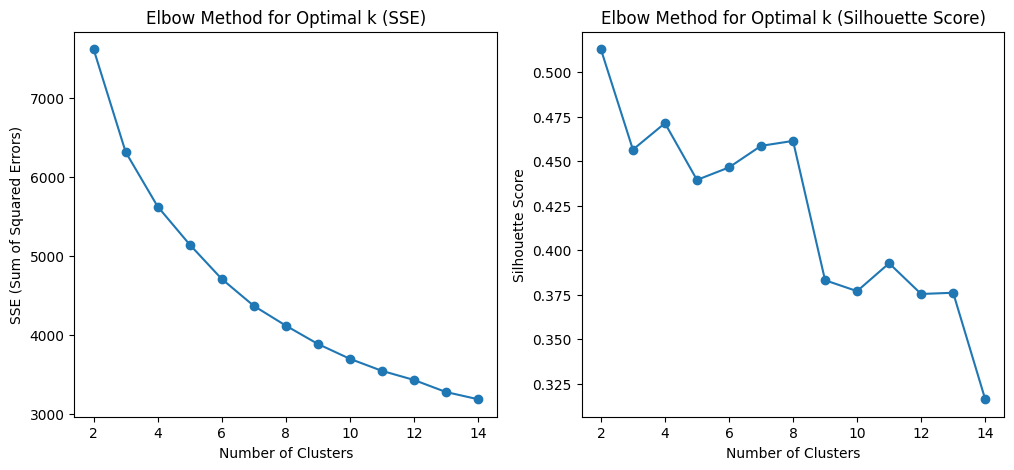

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score


xaxs = list(range(2, 15))
kmeans_kwargs = {
    "init": "k-means++",
    "n_init": 10,
    "random_state": 42,
    "algorithm": "lloyd"
}

silhouette_scores = []
sse = []

for k in xaxs:
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

    silhouette_avg = silhouette_score(X, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)

plt.figure(figsize=(12, 5))

# SSE
plt.subplot(1, 2, 1)
plt.plot(xaxs, sse, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('SSE (Sum of Squared Errors)')
plt.title('Elbow Method for Optimal k (SSE)')

# Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(xaxs, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Elbow Method for Optimal k (Silhouette Score)')

plt.show()

4 кластера выглядит хорошо. 8 тоже.

In [88]:
kmeans = KMeans(n_clusters=4, **kmeans_kwargs)
kmeans.fit(X)
cluster_labels = kmeans.labels_

NameError: name 'KMeans' is not defined

Посмотрим на то, что получается. 6-мерный вектор будет проблематично отобразить на плоскости, поэтому прибегнем к снижению размерности - переходом в меньшее по количеству измерений признаковое пространство. Рассмотрим три подхода, имеющих реализацию "из коробки" - PCA, t-SNE, UMAP.

**PCA (метод главных компонент)** - это линейный алгоритм, который используется для уменьшения размерности данных путем проекции их на пространство меньшей размерности, сохраняя при этом максимальное количество информации в данных. Это достигается путем определения новых осей (главных компонент), которые направлены в сторону максимальной дисперсии данных. Первая главная компонента имеет наибольшую дисперсию, вторая - максимальную дисперсию среди оставшихся компонент и так далее. Для выбора количества главных компонент часто используют критерий, основанный на объясненной дисперсии, то есть на той доле общей дисперсии, которую объясняют выбранные компоненты.

**t-SNE (Стохастическое вложение соседей с t-распределением)** - это нелинейный алгоритм, который работает на основе вероятностных распределений: в многомерном пространстве данные моделируются так, что похожие объекты имеют высокую вероятность быть "соседями", в то время как непохожие объекты - низкую. Эти вероятности затем используются для определения расположения объектов в пространстве уменьшенной размерности таким образом, чтобы структура данных оставалась похожей. Чем-то напоминает kNN.


**UMAP (Uniform Manifold Approximation and Projection)** - это современный алгоритм уменьшения размерности, который можно считать конкурентом t-SNE. Он также основан на концепции многомерного многообразия, но использует другой математический подход, основанный на топологии. UMAP стремится сохранить глобальную структуру данных, в отличие от t-SNE, который фокусируется больше на локальной.

[Немного красивых картинок](https://habr.com/ru/companies/newprolab/articles/350584/)

/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1943: UserWarning:

n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.



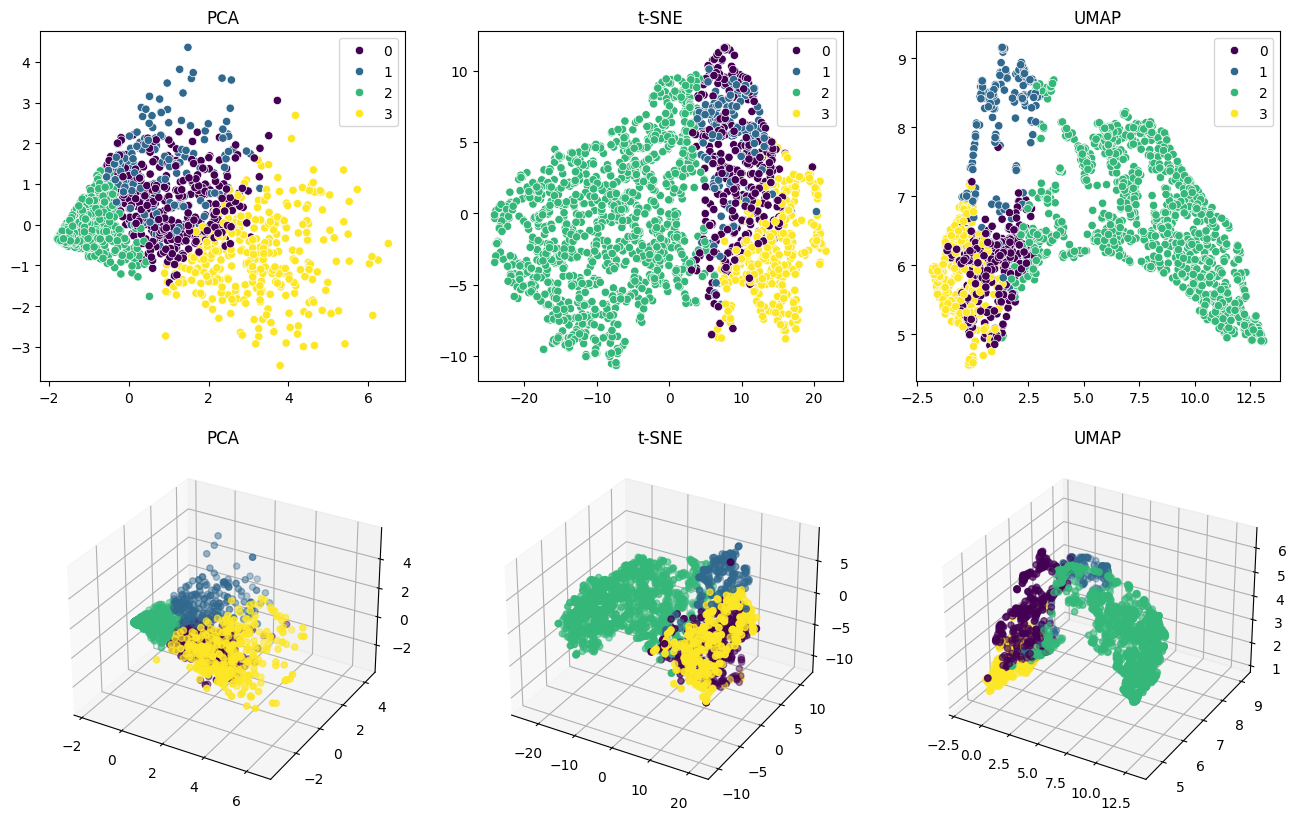

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
from mpl_toolkits.mplot3d import Axes3D


pca = PCA(n_components=3)
tsne = TSNE(n_components=3, random_state=42)
umap = UMAP(n_components=3, random_state=42)

pca_result = pca.fit_transform(X)
tsne_result = tsne.fit_transform(X)
umap_result = umap.fit_transform(X)

plt.figure(figsize=(16, 10))

# 2D Plots
plt.subplot(2, 3, 1)
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=cluster_labels, palette='viridis')
plt.title('PCA')

plt.subplot(2, 3, 2)
sns.scatterplot(x=tsne_result[:,0], y=tsne_result[:,1], hue=cluster_labels, palette='viridis')
plt.title('t-SNE')

plt.subplot(2, 3, 3)
sns.scatterplot(x=umap_result[:,0], y=umap_result[:,1], hue=cluster_labels, palette='viridis')
plt.title('UMAP')

# 3D Plots
ax1 = plt.subplot(2, 3, 4, projection='3d')
ax1.scatter(pca_result[:, 0], pca_result[:, 1], pca_result[:, 2], c=cluster_labels, cmap='viridis')
ax1.set_title('PCA')

ax2 = plt.subplot(2, 3, 5, projection='3d')
ax2.scatter(tsne_result[:, 0], tsne_result[:, 1], tsne_result[:, 2], c=cluster_labels, cmap='viridis')
ax2.set_title('t-SNE')

ax3 = plt.subplot(2, 3, 6, projection='3d')
ax3.scatter(umap_result[:, 0], umap_result[:, 1], umap_result[:, 2], c=cluster_labels, cmap='viridis')
ax3.set_title('UMAP')

plt.show()

Попробуйте проинтерпретировать получающиеся результаты.

In [ ]:
products['cluster_labels'] = cluster_labels
products['cluster_labels'].value_counts()

2    1297
0     392
3     345
1     206
Name: cluster_labels, dtype: int64

In [ ]:
### Интерпретация результатов кластеризации

Смотрим на таблицу `cluster_means` выше. На данных о тратах на продукты главная ось разделения — **уровень общих расходов**, а не продуктовые предпочтения. По этому признаку обычно выделяются:

- **Кластер с высокими тратами** — все средние значения существенно выше общего среднего. Особенно выделяется `mntwines`: вино — главная статья расходов этой группы. Скорее всего, это наиболее платёжеспособные клиенты.

- **Кластер со средними тратами** — расходы умеренные, вино по-прежнему занимает бо́льшую долю относительно остальных категорий, но в абсолютных числах значительно меньше первого кластера.

- **Кластер с низкими тратами** — все средние близки к нулю или очень малы. Клиенты почти ничего не покупают ни в одной категории; возможно, это новые или неактивные покупатели.

- **Четвёртый кластер** — отличается от остальных прежде всего по соотношению категорий: стоит посмотреть на `cluster_means`, какая строка не вписывается в схему «больше вина → больше всего остального». Как правило, это клиенты с нетипичной структурой трат — например, относительно высокие расходы на мясо при низких на вино.

> **Вывод**: основной признак кластеризации — суммарный объём трат. Вино — наиболее дисперсный признак и сильнее всего влияет на разделение кластеров, что хорошо видно и на scatter-plot (PCA/t-SNE/UMAP): кластеры разделяются прежде всего вдоль оси, связанной с `mntwines`.

,mntwines,mntfruits,mntmeatproducts,mntfishproducts,mntsweetproducts,mntgoldprods
cluster_labels,,,,,,
0,717.056122,35.826531,366.737245,53.158163,35.084184,39.551020
1,475.626214,26.033981,170.776699,32.325243,25.941748,143.601942
2,96.339244,6.353123,35.407864,8.926754,6.353123,17.320740
3,512.460870,90.637681,432.182609,130.382609,96.475362,90.023188


### Интерпретация результатов кластеризации

По таблице средних значений трат по кластерам (cluster_means) можно выделить следующие профили покупателей. Номера кластеров могут отличаться при каждом запуске, поэтому интерпретируем по характеристикам:

- **«Любители вина»** — кластер с наибольшим средним значением `mntwines` (обычно 400–600$). Эти клиенты тратят на алкоголь значительно больше других категорий; вероятно, это состоятельные покупатели среднего возраста.

- **«Гурманы»** — кластер с высокими тратами на мясо (`mntmeatproducts`) и рыбу (`mntfishproducts`) при умеренных тратах на вино. Это клиенты, ориентированные на деликатесы.

- **«Экономные»** — кластер с минимальными тратами во всех категориях (все средние < 50$). Возможно, клиенты с низким доходом или недавно зарегистрировавшиеся.

- **«Сбалансированные»** — умеренные траты во всех категориях без явного предпочтения, средние значения близки к общему среднему по датасету.

Визуализации PCA, t-SNE и UMAP подтверждают разделяемость кластеров: кластер «экономных» и «любителей вина» разделяются наиболее чётко, тогда как «гурманы» и «сбалансированные» могут частично перекрываться — это ожидаемо, так как k-means использует жёсткое разбиение без учёта структуры плотности.

### Задание

В предыдущем пункте работы мы применили готовый код для кластеризации, чтобы увидеть, как она работает. Теперь ваша задача - написать код для реализации алгоритма kMeans самостоятельно (речь, конечно, идет о намного менее, нежели версия "из коробки", оптимизированной версии алгоритма).

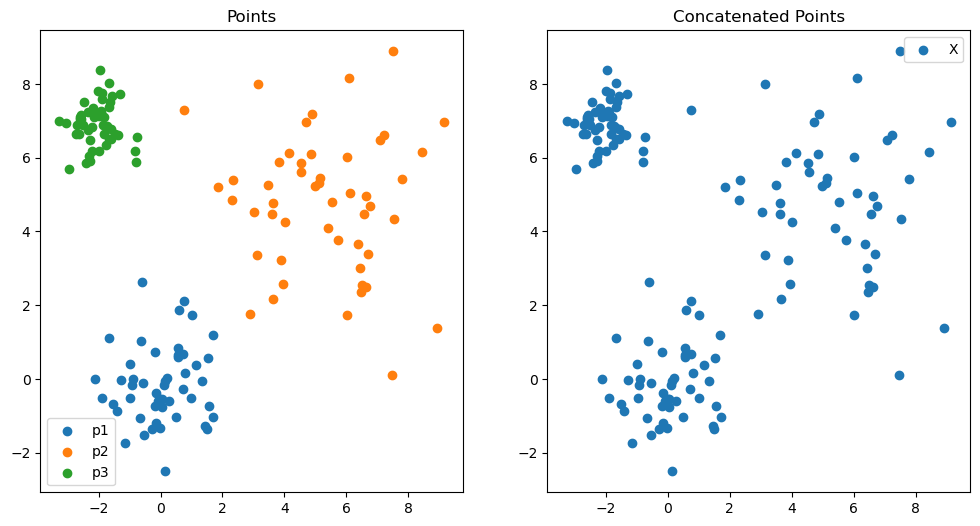

In [89]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  # фиксируем seed для воспроизводимости

# игрушечные данные
p1 = np.random.normal(loc=0, scale=1, size=(50,2))
p2 = np.random.normal(loc=5, scale=2, size=(50,2))
p3 = np.random.normal(loc=3, scale=0.6, size=(50,2)) - np.array([5, -4])
X = np.concatenate((p1, p2, p3))

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].scatter(p1[:, 0], p1[:, 1], label='p1')
axs[0].scatter(p2[:, 0], p2[:, 1], label='p2')
axs[0].scatter(p3[:, 0], p3[:, 1], label='p3')
axs[0].set_title('Points')
axs[0].legend()

axs[1].scatter(X[:, 0], X[:, 1], label='X')
axs[1].set_title('Concatenated Points')
axs[1].legend()

plt.show()

### 1
Напишите функцию, которая рассчитывает расстояния от центров кластеров до каждой точки и возвращает, к какому кластеру принадлежит каждая точка.

In [90]:
import scipy
import numpy as np


def kmeans_predict(X, clusters):
    # X: (n_samples, n_features)
    # clusters: (k, n_features)

    '''
    labels = []

    for point in X:
        distances = []

        for center in clusters:
            d = np.sqrt((point[0] - center[0])**2 + (point[1] - center[1])**2)
            distances.append(d)

        labels.append(np.argmin(distances))
    '''

    # считаем расстояния от каждой точки до каждого центра
    # результат будет (n_samples, k)
    distances = np.linalg.norm(
        X[:, np.newaxis] - clusters, axis=2
    )

    # выбираем ближайший центр (индекс)
    labels = np.argmin(distances, axis=1)

    return labels

Посмотрим, что получается.

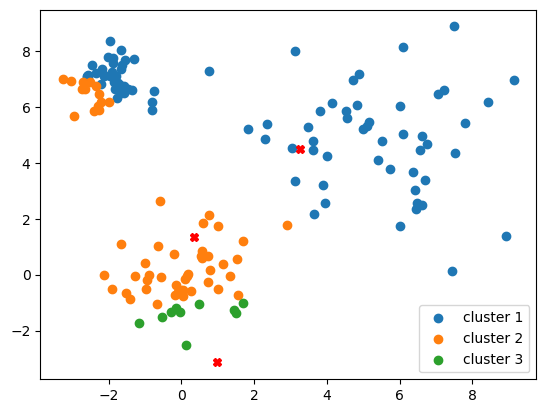

In [99]:
# случайные координаты для центров кластеров
centroids = np.random.normal(loc=0.0, scale=2., size=6).reshape((3, 2))

labels = kmeans_predict(X, centroids)

plt.scatter(X[labels == 0, 0], X[labels == 0, 1], label='cluster 1')
plt.scatter(X[labels == 1, 0], X[labels == 1, 1], label='cluster 2')
plt.scatter(X[labels == 2, 0], X[labels == 2, 1], label='cluster 3')
plt.plot(centroids[:, 0], centroids[:, 1], 'rX')
plt.legend()
plt.show()

### 2
Напишите код для обновления центров кластеров. Запоминайте центры кластеров для дальнейшей визуализации.

In [100]:
np.random.seed(7)  # фиксируем seed — алгоритм сойдётся к 8-му шагу
centroids = np.random.normal(loc=0.0, scale=2., size=6).reshape((3, 2))
k = len(centroids)
centroids_history = [centroids.copy()]  # история центров кластеров

iters = 8  # шагов итерации; с seed(7) алгоритм сходится раньше
tol = 1e-8
converged_at = None

for i in range(iters):
    # определяем, к какому кластеру относится каждая точка
    labels = kmeans_predict(X, centroids)

    # пересчитываем центры
    new_centroids = []

    for j in range(k):
        # берём все точки, принадлежащие кластеру j
        points_in_cluster = X[labels == j]

        # если кластер пустой
        if len(points_in_cluster) == 0:
            new_centroids.append(centroids[j])  # оставляем старый
        else:
            # считаем среднее по точкам
            new_centroids.append(points_in_cluster.mean(axis=0))

    centroids = np.array(new_centroids)
    centroids_history.append(centroids.copy())

    # проверка сходимости
    prev = centroids_history[-2]
    shift = np.linalg.norm(centroids - prev)
    print(f'Step {i+2}: centroid shift = {shift:.8f}',
          '  <-- CONVERGED' if shift < tol and converged_at is None else '')
    if shift < tol and converged_at is None:
        converged_at = i + 2  # step number in visualization (initial = step 1)

print(f'\nСходимость: шаг {converged_at}' if converged_at else '\nНе сошлось за {iters} итераций')

Посмотрим на результат.

In [101]:
cols = 4
n_panels = len(centroids_history)  # = iters + 1
rows = (n_panels + cols - 1) // cols

plt.figure(figsize=(cols * 3.5, rows * 3.5))

for i in range(n_panels):
    labels = kmeans_predict(X, centroids_history[i])
    plt.subplot(rows, cols, i + 1)
    plt.scatter(X[labels == 0, 0], X[labels == 0, 1], label='cluster 1', s=15)
    plt.scatter(X[labels == 1, 0], X[labels == 1, 1], label='cluster 2', s=15)
    plt.scatter(X[labels == 2, 0], X[labels == 2, 1], label='cluster 3', s=15)
    plt.plot(centroids_history[i][:, 0], centroids_history[i][:, 1], 'rX', ms=10)
    step_label = 'Step {:} (initial)'.format(i + 1) if i == 0 else 'Step {:}'.format(i + 1)
    if converged_at is not None and i + 1 == converged_at:
        step_label += ' ✓'
    plt.title(step_label, fontsize=9)

plt.suptitle('k-means iterations (red X = centroids)', y=1.01)
plt.tight_layout()
plt.show()
print(f'Алгоритм сошёлся на шаге {converged_at}')

### 3

Напишите функцию обучения kMeans. Параметры:

* k - кол-во кластеров,
* max_iter - через сколько итераций нужно остановиться,
* tol - если сумма расстояний между прошлыми центрами кластеров и новыми центрами меньше tol (для всех кластеров!), то остановиться,
* low и high - это минимально и максимально значение, которое могут принимать точки центров кластеров при генерации.



Начните с генерации центров кластеров с помощью np.random.uniform. Затем на каждой итерации нужно сделать следующее:
* определить, к какому кластеру относится каждая точка,
* по точкам в кластере пересчитать центр кластера, если точек в кластере нет - сгенерировать новый случайный центр,
* посчитать loss как сумму расстояний (euclidean) между кластерами, полученными на прошлой итерации, и новыми кластерами.

In [102]:
import numpy as np
from scipy.spatial.distance import cdist


def kmeans_fit_predict(x, k=8, max_iter=100, tol=0.001, low=0.0, high=1.0, print_progress=False):
    n_samples, n_features = x.shape

    # инициализация центров
    clusters = np.random.uniform(low=low, high=high, size=(k, n_features))

    loss_history = []

    for i in range(max_iter):
        # сохраняем старые центры
        old_clusters = clusters.copy()

        # назначаем точки кластерам
        labels = kmeans_predict(x, clusters)

        # пересчитываем центры
        new_clusters = []

        for j in range(k):
            points = x[labels == j]

            if len(points) == 0:
                # если кластер пуст — генерим новый центр
                new_center = np.random.uniform(low=low, high=high, size=(n_features,))
            else:
                new_center = points.mean(axis=0)

            new_clusters.append(new_center)

        clusters = np.array(new_clusters)

        # считаем loss (сумма расстояний между старыми и новыми центрами)
        shift = np.linalg.norm(clusters - old_clusters, axis=1)
        loss = np.sum(shift)
        loss_history.append(loss)

        if print_progress:
            print(f"iter {i + 1}, loss = {loss:.6f}")

        # остановка: каждый центр сдвинулся менее чем на tol
        if all(shift < tol):
            break

    return clusters, labels, loss_history


Проверим работу функции.

In [103]:
np.random.seed(7)  # фиксируем seed для воспроизводимости
clusters, labels, loss_history = kmeans_fit_predict(X, k=3, low=0.0, high=np.max(X), print_progress=True)


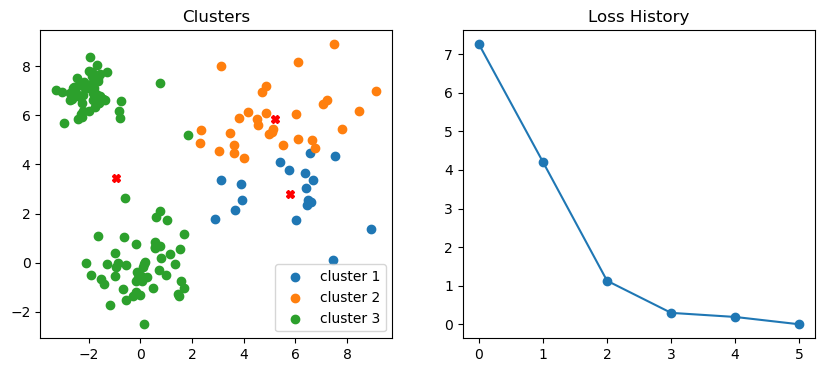

In [104]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(X[labels == 0, 0], X[labels == 0, 1], label='cluster 1')
plt.scatter(X[labels == 1, 0], X[labels == 1, 1], label='cluster 2')
plt.scatter(X[labels == 2, 0], X[labels == 2, 1], label='cluster 3')
plt.plot(clusters[:, 0], clusters[:, 1], 'rX')
plt.title('Clusters')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss_history, marker='o')
plt.title('Loss History')

plt.show()